# Rookie Projections

Separate projection pipeline for rookie player-seasons (`rookie == 1`).

**Sections**
1. Data loading — filter training data to rookies
2. EDA — wRC+ distributions by PA threshold and age group

In [30]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

data_path = Path.cwd()
while not (data_path / "data" / "fangraphs" / "fg_hitters.csv").exists() and data_path != data_path.parent:
    data_path = data_path.parent

DATA_DIR = data_path


## 1. Load Data

In [31]:
train_df = pd.read_csv(DATA_DIR / "data" / "fg_builds" / "fg_hitters_train.csv")
test_df  = pd.read_csv(DATA_DIR / "data" / "fg_builds" / "fg_hitters_test.csv")

# Rookie seasons only (from training data)
rookies = train_df[train_df["rookie"] == 1].copy()

# Age groups
bins   = [0, 22, 25, 99]
labels = ["≤ 22", "23–25", "≥ 26"]
rookies["age_group"] = pd.cut(rookies["Age"], bins=bins, labels=labels)

print(f"Rookie player-seasons in training data: {len(rookies):,}")
print(f"  of which 50+ PA: {(rookies['PA'] >= 50).sum():,}")
print()
print("Age group breakdown:")
print(rookies["age_group"].value_counts().reindex(labels).rename("n").to_frame())


Rookie player-seasons in training data: 797
  of which 50+ PA: 450

Age group breakdown:
             n
age_group     
≤ 22       155
23–25      400
≥ 26       242


## 2. EDA — Rookie wRC+ Distributions

/var/folders/3f/5z6bhnqn1fv15360tr2wfskr0000gn/T/ipykernel_42543/3056281154.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/3f/5z6bhnqn1fv15360tr2wfskr0000gn/T/ipykernel_42543/3056281154.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/3f/5z6bhnqn1fv15360tr2wfskr0000gn/T/ipykernel_42543/3056281154.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/3f/5z6bhnqn1fv15360tr2wfskr0000gn/T/ipykernel_42543/3056281154.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since M

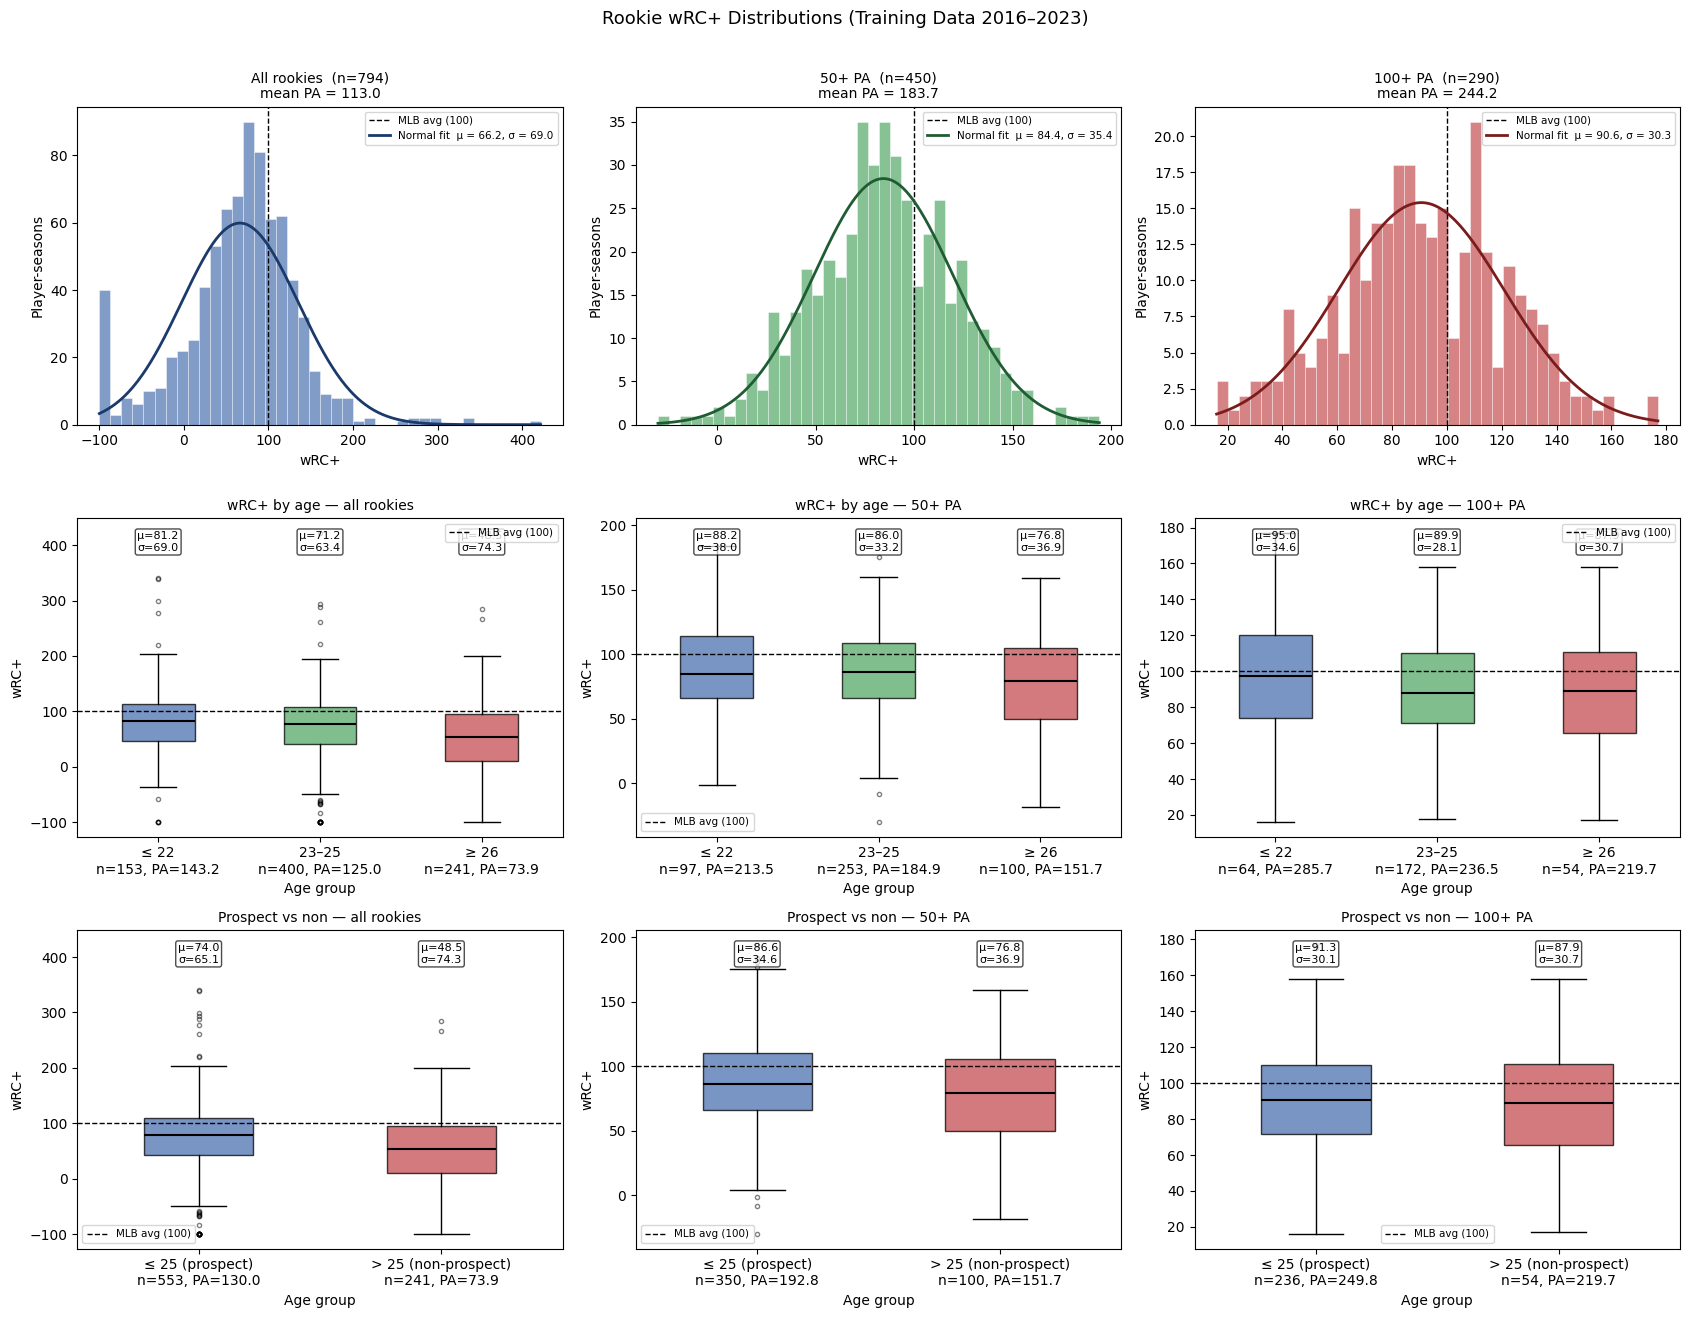

In [32]:
from scipy import stats

rooks_all = rookies.dropna(subset=["wRC+"]).copy()
rooks_50  = rooks_all[rooks_all["PA"] >= 50].copy()
rooks_100 = rooks_all[rooks_all["PA"] >= 100].copy()

AGE_ORDER   = ["≤ 22", "23–25", "≥ 26"]
AGE_COLORS  = {"≤ 22": "#4C72B0", "23–25": "#55A868", "≥ 26": "#C44E52"}
PROS_ORDER  = ["≤ 25 (prospect)", "> 25 (non-prospect)"]
PROS_COLORS = {"≤ 25 (prospect)": "#4C72B0", "> 25 (non-prospect)": "#C44E52"}

for df in [rooks_all, rooks_50, rooks_100]:
    df["prospect_group"] = pd.cut(
        df["Age"], bins=[0, 25, 99],
        labels=["≤ 25 (prospect)", "> 25 (non-prospect)"]
    )

fig, axes = plt.subplots(3, 3, figsize=(17, 13))
fig.subplots_adjust(hspace=0.55, wspace=0.35)


def overlay_normal(ax, data, color, n_pts=300):
    mu, sigma = stats.norm.fit(data)
    x = np.linspace(data.min(), data.max(), n_pts)
    bin_width = (data.max() - data.min()) / 40
    ax.plot(x, stats.norm.pdf(x, mu, sigma) * len(data) * bin_width,
            color=color, linewidth=2,
            label=f"Normal fit  \u03bc = {mu:.1f}, \u03c3 = {sigma:.1f}")


def annotate_boxes(ax, groups):
    y_min, y_max = ax.get_ylim()
    y_top = y_max - 0.04 * (y_max - y_min)
    for i, data in enumerate(groups, start=1):
        mu, sigma = stats.norm.fit(data)
        ax.text(i, y_top, f"\u03bc={mu:.1f}\n\u03c3={sigma:.1f}",
                ha="center", va="top", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))


def hist_panel(ax, data, color, fit_color, title):
    mean_pa = data["PA"].mean()
    ax.hist(data["wRC+"], bins=40, color=color, edgecolor="white", linewidth=0.4, alpha=0.7)
    ax.axvline(100, color="black", linestyle="--", linewidth=1, label="MLB avg (100)")
    overlay_normal(ax, data["wRC+"].values, color=fit_color)
    ax.set_title(f"{title}\nmean PA = {mean_pa:.1f}", fontsize=10)
    ax.set_xlabel("wRC+"); ax.set_ylabel("Player-seasons")
    ax.legend(fontsize=7.5)


def box_panel(ax, data, group_col, order, colors, title):
    groups    = [data[data[group_col] == g]["wRC+"].dropna().values for g in order]
    pa_means  = [data[data[group_col] == g]["PA"].mean() for g in order]
    ns        = [len(g) for g in groups]
    labels    = [f"{g}\nn={n}, PA={pa:.1f}" for g, n, pa in zip(order, ns, pa_means)]
    bp = ax.boxplot(
        groups,
        labels=labels,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=1.5),
        flierprops=dict(marker="o", markersize=3, alpha=0.5),
        widths=0.45,
    )
    for patch, grp in zip(bp["boxes"], order):
        patch.set_facecolor(colors[grp]); patch.set_alpha(0.75)
    ax.axhline(100, color="black", linestyle="--", linewidth=1, label="MLB avg (100)")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Age group"); ax.set_ylabel("wRC+"); ax.legend(fontsize=7.5)
    annotate_boxes(ax, groups)


# ── Row 0: histograms ─────────────────────────────────────────────────────
hist_panel(axes[0, 0], rooks_all, "#4C72B0", "#1a3a6b", f"All rookies  (n={len(rooks_all):,})")
hist_panel(axes[0, 1], rooks_50,  "#55A868", "#1f5c33", f"50+ PA  (n={len(rooks_50):,})")
hist_panel(axes[0, 2], rooks_100, "#C44E52", "#7a1c1c", f"100+ PA  (n={len(rooks_100):,})")

# ── Row 1: boxplots by 3-way age group ───────────────────────────────────
box_panel(axes[1, 0], rooks_all, "age_group", AGE_ORDER,  AGE_COLORS,  "wRC+ by age — all rookies")
box_panel(axes[1, 1], rooks_50,  "age_group", AGE_ORDER,  AGE_COLORS,  "wRC+ by age — 50+ PA")
box_panel(axes[1, 2], rooks_100, "age_group", AGE_ORDER,  AGE_COLORS,  "wRC+ by age — 100+ PA")

# ── Row 2: boxplots prospect vs non-prospect ──────────────────────────────
box_panel(axes[2, 0], rooks_all, "prospect_group", PROS_ORDER, PROS_COLORS, "Prospect vs non — all rookies")
box_panel(axes[2, 1], rooks_50,  "prospect_group", PROS_ORDER, PROS_COLORS, "Prospect vs non — 50+ PA")
box_panel(axes[2, 2], rooks_100, "prospect_group", PROS_ORDER, PROS_COLORS, "Prospect vs non — 100+ PA")

fig.suptitle("Rookie wRC+ Distributions (Training Data 2016–2023)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
## Back-of-the-envelope calculations for true talent variance 
## for rookies (using SD = 380 from Bayesian MARCEL):
# 
#  Prospects(<= 25): Normal(86,12)
# Non-prospects(> 25): Normal(76,5)



## 3. Rookie Role Models

Two Bayesian ordered logistic regression models fit on rookie seasons only:

- **Model A** — inputs: `wRC+`, `Age`
- **Model B** — input: `wRC+` only

Both share the same ordered structure: bench < platoon < starter.

In [33]:
import pymc as pm
import arviz as az
import scipy as sp
import pickle

ROLE_ORDER = ['bench', 'platoon', 'starter']

# Filter to rookie rows with valid role and predictors
rook_model = (
    rookies
    .dropna(subset=["wRC+", "Age", "role"])
    .query("role in @ROLE_ORDER")
    .copy()
    .reset_index(drop=True)
)
rook_model["role_code"] = rook_model["role"].map(
    {r: i for i, r in enumerate(ROLE_ORDER)}
)

print(f"Modeling rows: {len(rook_model):,}")
print("Role distribution:")
print(rook_model["role"].value_counts().reindex(ROLE_ORDER))


def fit_rookie_model(df, feature_cols, label="model"):
    """
    Fit a Bayesian ordered logistic regression on rookie rows.
    Continuous features are z-scored. Returns (trace, meta).
    """
    K = len(ROLE_ORDER)

    work = df.dropna(subset=feature_cols + ["role_code"]).reset_index(drop=True)
    print(f"\n=== {label} ({len(work):,} obs) ===")
    print(f"Features: {feature_cols}")

    X = work[feature_cols].copy()
    scaler = {}
    for col in feature_cols:
        if work[col].nunique() > 2:
            mu, sigma = work[col].mean(), work[col].std()
            if sigma > 0:
                X[col] = (X[col] - mu) / sigma
                scaler[col] = {"mean": float(mu), "std": float(sigma)}

    X_np = X.to_numpy(dtype=float)
    y_np = work["role_code"].to_numpy(dtype=int)

    with pm.Model() as model:
        X_data = pm.Data("X", X_np, mutable=True)
        y_data = pm.Data("y", y_np, mutable=True)
        beta = pm.Normal("beta", mu=0, sigma=2.5, shape=X_np.shape[1])
        cutpoints = pm.Normal(
            "cutpoints", mu=0, sigma=5, shape=K - 1,
            transform=pm.distributions.transforms.ordered,
            initval=np.linspace(-1.5, 1.5, K - 1),
        )
        eta = pm.math.dot(X_data, beta)
        pm.OrderedLogistic("role", eta=eta, cutpoints=cutpoints, observed=y_data)

    with model:
        trace = pm.sample(
            draws=1000, tune=1000, target_accept=0.9,
            random_seed=42, nuts_sampler="numpyro", progressbar=True,
        )
        pm.sample_posterior_predictive(trace, extend_inferencedata=True)

    summary = az.summary(trace, var_names=["beta", "cutpoints"], round_to=3)
    summary.index = (
        [f"beta[{c}]" for c in feature_cols]
        + [f"cutpoint[{ROLE_ORDER[i]}/{ROLE_ORDER[i+1]}]" for i in range(K - 1)]
    )
    print(summary.to_string())

    meta = {
        "label": label,
        "feature_cols": feature_cols,
        "scaler": scaler,
        "role_order": ROLE_ORDER,
        "summary": summary,
        "n_obs": len(work),
    }
    return trace, meta, work


Modeling rows: 792
Role distribution:
role
bench      506
platoon    174
starter    112
Name: count, dtype: int64


In [34]:
trace_a, meta_a, work_a = fit_rookie_model(rook_model, ["wRC+", "Age"], label="Model A (wRC+ + Age)")
trace_b, meta_b, work_b = fit_rookie_model(rook_model, ["wRC+"],        label="Model B (wRC+ only)")



=== Model A (wRC+ + Age) (792 obs) ===
Features: ['wRC+', 'Age']


Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:00<?, ?it/s]




Running chain 2: 100%|██████████| 2000/2000 [00:00<00:00, 2270.35it/s] 
Sampling: [role]


                            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
beta[wRC+]                 0.620  0.097   0.446    0.807      0.001    0.001  4221.831  2706.488  1.002
beta[Age]                 -0.643  0.093  -0.814   -0.469      0.001    0.001  4567.247  2799.368  1.000
cutpoint[bench/platoon]    0.669  0.083   0.510    0.828      0.001    0.001  3969.281  3011.459  1.000
cutpoint[platoon/starter]  2.049  0.111   1.842    2.250      0.002    0.001  4779.521  3262.775  1.001

=== Model B (wRC+ only) (792 obs) ===
Features: ['wRC+']


Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:00<?, ?it/s]


Running chain 3: 100%|██████████| 2000/2000 [00:00<00:00, 2756.57it/s]

Running chain 2: 100%|██████████| 2000/2000 [00:00<00:00, 2746.12it/s] 
Sampling: [role]


                            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
beta[wRC+]                 0.690  0.093   0.521    0.865      0.002    0.001  3098.229  2921.682  1.002
cutpoint[bench/platoon]    0.619  0.079   0.465    0.759      0.001    0.001  3352.480  2669.095  1.001
cutpoint[platoon/starter]  1.923  0.107   1.716    2.113      0.002    0.001  4150.876  2846.404  1.001


In-sample accuracy
  Model A (wRC+ + Age): 63.4%  (502 / 792)
  Model B (wRC+ only):  62.0%  (491 / 792)

Model A — by role:
role
bench      95.8%
platoon     0.0%
starter    15.2%
Name: correct, dtype: object

Model B — by role:
role
bench      96.8%
platoon     0.0%
starter     0.9%
Name: correct, dtype: object



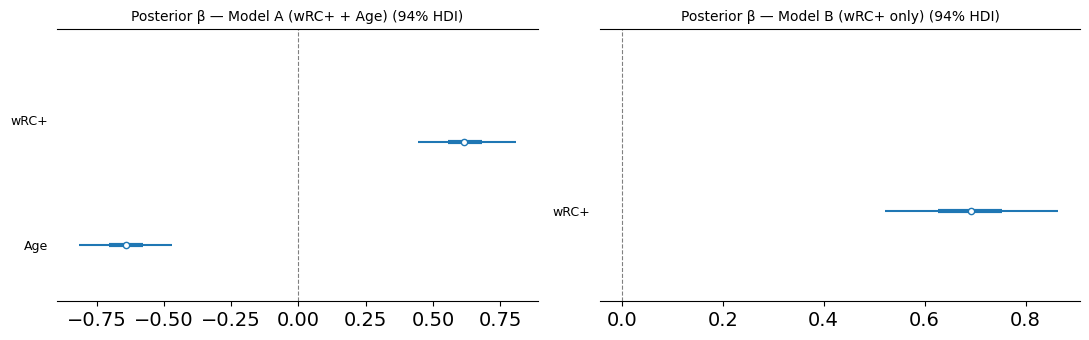

In [35]:
def predict_rookie_roles(trace, meta, work):
    """Return DataFrame with predicted role and accuracy for each obs."""
    feature_cols = meta["feature_cols"]
    scaler       = meta["scaler"]
    K            = len(ROLE_ORDER)

    X = work[feature_cols].copy()
    for col, params in scaler.items():
        X[col] = (X[col] - params["mean"]) / params["std"]
    X_np = X.to_numpy(dtype=float)

    beta_draws = trace.posterior["beta"].values.reshape(-1, len(feature_cols))
    cp_draws   = trace.posterior["cutpoints"].values.reshape(-1, K - 1)
    eta        = X_np @ beta_draws.T
    cum        = sp.special.expit(cp_draws[np.newaxis, :, :] - eta[:, :, np.newaxis])
    pad0       = np.zeros((len(work), beta_draws.shape[0], 1))
    pad1       = np.ones( (len(work), beta_draws.shape[0], 1))
    probs      = np.diff(np.concatenate([pad0, cum, pad1], axis=2), axis=2)
    mean_probs = probs.mean(axis=1)
    pred_code  = mean_probs.argmax(axis=1)

    out = work[["Name", "Season", "role", "role_code"]].copy()
    out["pred_role"] = [ROLE_ORDER[c] for c in pred_code]
    out["correct"]   = pred_code == out["role_code"].values
    for i, r in enumerate(ROLE_ORDER):
        out[f"p_{r}"] = mean_probs[:, i]
    return out


preds_a = predict_rookie_roles(trace_a, meta_a, work_a)
preds_b = predict_rookie_roles(trace_b, meta_b, work_b)

# Accuracy summary
print("In-sample accuracy")
print(f"  Model A (wRC+ + Age): {preds_a['correct'].mean():.1%}  ({preds_a['correct'].sum()} / {len(preds_a)})")
print(f"  Model B (wRC+ only):  {preds_b['correct'].mean():.1%}  ({preds_b['correct'].sum()} / {len(preds_b)})")
print()

for label, preds in [("Model A", preds_a), ("Model B", preds_b)]:
    print(f"{label} — by role:")
    print(preds.groupby("role")["correct"].mean().reindex(ROLE_ORDER).map("{:.1%}".format))
    print()

# Coefficient forest plot
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, trace, meta in [(axes[0], trace_a, meta_a), (axes[1], trace_b, meta_b)]:
    az.plot_forest(trace, var_names=["beta"], combined=True, hdi_prob=0.94, ax=ax)
    ax.set_title(f"Posterior β — {meta['label']} (94% HDI)", fontsize=10)
    ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.set_yticks(range(len(meta["feature_cols"])))
    ax.set_yticklabels(meta["feature_cols"][::-1], fontsize=9)
plt.tight_layout()
plt.show()


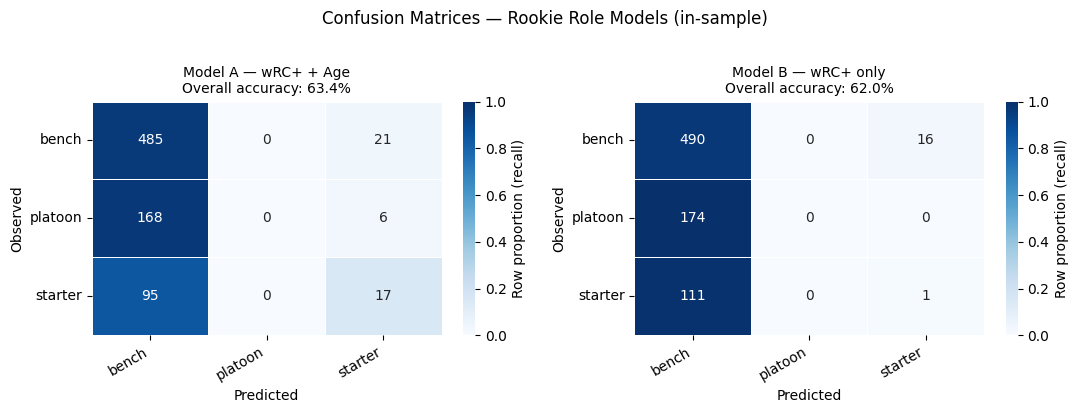

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, preds, title in [
    (axes[0], preds_a, "Model A — wRC+ + Age"),
    (axes[1], preds_b, "Model B — wRC+ only"),
]:
    cm = pd.crosstab(
        preds["role"], preds["pred_role"],
        rownames=["Observed"], colnames=["Predicted"],
    ).reindex(index=ROLE_ORDER, columns=ROLE_ORDER, fill_value=0)

    # Normalise by row (recall per class)
    cm_norm = cm.div(cm.sum(axis=1), axis=0)

    sns.heatmap(
        cm_norm, annot=cm, fmt="d", ax=ax,
        cmap="Blues", vmin=0, vmax=1,
        linewidths=0.5, linecolor="white",
        cbar_kws={"label": "Row proportion (recall)"},
    )
    ax.set_title(f"{title}\nOverall accuracy: {preds['correct'].mean():.1%}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Observed")
    ax.set_xticklabels(ROLE_ORDER, rotation=30, ha="right")
    ax.set_yticklabels(ROLE_ORDER, rotation=0)

plt.suptitle("Confusion Matrices — Rookie Role Models (in-sample)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


In [37]:
# 2024 rookie predictions — Model A (wRC+ + Age)
rookies_2024 = (
    test_df[test_df["rookie"] == 1]
    .dropna(subset=["wRC+", "Age"])
    .copy()
    .reset_index(drop=True)
)
rookies_2024["role_code"] = rookies_2024["role"].map(
    {r: i for i, r in enumerate(ROLE_ORDER)}
)

# Scale using training-data statistics from meta_a
feature_cols = meta_a["feature_cols"]
X_2024 = rookies_2024[feature_cols].copy()
for col, params in meta_a["scaler"].items():
    X_2024[col] = (X_2024[col] - params["mean"]) / params["std"]
X_np_2024 = X_2024.to_numpy(dtype=float)

# Posterior predictive probabilities
K          = len(ROLE_ORDER)
beta_draws = trace_a.posterior["beta"].values.reshape(-1, len(feature_cols))
cp_draws   = trace_a.posterior["cutpoints"].values.reshape(-1, K - 1)
eta        = X_np_2024 @ beta_draws.T
cum        = sp.special.expit(cp_draws[np.newaxis, :, :] - eta[:, :, np.newaxis])
pad0       = np.zeros((len(rookies_2024), beta_draws.shape[0], 1))
pad1       = np.ones( (len(rookies_2024), beta_draws.shape[0], 1))
probs      = np.diff(np.concatenate([pad0, cum, pad1], axis=2), axis=2)
mean_probs = probs.mean(axis=1)

preds_2024 = rookies_2024[["Name", "Team", "Age", "wRC+", "primary_pos", "role"]].copy()
preds_2024 = preds_2024.rename(columns={"role": "actual_role"})
for i, r in enumerate(ROLE_ORDER):
    preds_2024[f"p_{r}"] = mean_probs[:, i].round(3)
preds_2024["pred_role"] = [ROLE_ORDER[c] for c in mean_probs.argmax(axis=1)]

# Sort by descending p_starter for readability
preds_2024 = preds_2024.sort_values("p_starter", ascending=False).reset_index(drop=True)

known = preds_2024["actual_role"].notna()
accuracy = (preds_2024.loc[known, "pred_role"] == preds_2024.loc[known, "actual_role"]).mean()
print(f"2024 rookie predictions: {len(preds_2024)} players")
print(f"Out-of-sample accuracy (known roles): {accuracy:.1%}  ({known.sum()} labelled)")
preds_2024


2024 rookie predictions: 108 players
Out-of-sample accuracy (known roles): 60.2%  (108 labelled)


,Name,Team,Age,wRC+,primary_pos,actual_role,p_bench,p_platoon,p_starter,pred_role
0,Dustin Harris,TEX,24,287.0,NaN,bench,0.194,0.289,0.517,starter
1,Jackson Chourio,MIL,20,118.0,LF,starter,0.268,0.322,0.410,starter
2,Luisangel Acuna,NYM,22,166.0,SS,bench,0.289,0.327,0.384,starter
3,Jackson Merrill,SDP,21,130.0,CF,starter,0.300,0.328,0.371,starter
4,James Wood,WSN,21,120.0,LF,starter,0.319,0.330,0.351,starter
...,...,...,...,...,...,...,...,...,...,...
103,Levi Jordan,CIN,28,-39.0,LF,bench,0.926,0.054,0.020,bench
104,Sandro Fabian,TEX,26,-100.0,LF,bench,0.926,0.054,0.020,bench
105,Eric Yang,CIN,26,-100.0,NaN,bench,0.926,0.054,0.020,bench
106,Chris Roller,MIL,27,-100.0,CF,bench,0.942,0.042,0.015,bench


In [44]:
# ── Edit these two values ────────────────────────────────────────────────
PLAYER_AGE  = 21
PLAYER_WRC  = 105
# ─────────────────────────────────────────────────────────────────────────

feature_cols = meta_a["feature_cols"]   # ["wRC+", "Age"]
raw_vals     = {"wRC+": PLAYER_WRC, "Age": PLAYER_AGE}

x = np.array([
    (raw_vals[col] - meta_a["scaler"][col]["mean"]) / meta_a["scaler"][col]["std"]
    for col in feature_cols
])

K          = len(ROLE_ORDER)
beta_draws = trace_a.posterior["beta"].values.reshape(-1, len(feature_cols))
cp_draws   = trace_a.posterior["cutpoints"].values.reshape(-1, K - 1)
eta        = x @ beta_draws.T                         # (n_draws,)
cum        = sp.special.expit(cp_draws - eta[:, np.newaxis])  # (n_draws, K-1)
pad0       = np.zeros((beta_draws.shape[0], 1))
pad1       = np.ones( (beta_draws.shape[0], 1))
probs      = np.diff(np.concatenate([pad0, cum, pad1], axis=1), axis=1)  # (n_draws, K)
mean_p     = probs.mean(axis=0)
hdi        = az.hdi(probs, hdi_prob=0.89)

print(f"Predicted role probabilities for Age={PLAYER_AGE}, wRC+={PLAYER_WRC}")
print(f"{'Role':<10}  {'Mean':>6}  {'89% HDI':>18}")
print("-" * 38)
for i, r in enumerate(ROLE_ORDER):
    lo, hi = hdi[i]
    print(f"{r:<10}  {mean_p[i]:>6.1%}  [{lo:.1%}, {hi:.1%}]")
print(f"\nPredicted role: {ROLE_ORDER[mean_p.argmax()]}")


Predicted role probabilities for Age=21, wRC+=105
Role          Mean             89% HDI
--------------------------------------
bench        34.9%  [29.6%, 40.1%]
platoon      33.0%  [29.6%, 36.2%]
starter      32.1%  [26.7%, 36.9%]

Predicted role: bench


/var/folders/3f/5z6bhnqn1fv15360tr2wfskr0000gn/T/ipykernel_42543/1093622019.py:23: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi        = az.hdi(probs, hdi_prob=0.89)


In [ ]:
# Save rookie Model A (wRC+ + Age) for use in the simulation pipeline
import pickle

save_dir = DATA_DIR / "data" / "model_runs" / "rookie_projections"
save_dir.mkdir(parents=True, exist_ok=True)

with open(save_dir / "rookie_model_a_trace.pkl", "wb") as f:
    pickle.dump(trace_a, f)
with open(save_dir / "rookie_model_a_meta.pkl", "wb") as f:
    pickle.dump(meta_a, f)

print(f"Saved rookie Model A → {save_dir}/")
print(f"  features : {meta_a['feature_cols']}")
print(f"  n_obs    : {meta_a['n_obs']:,}")
